# Taller de Aprendizaje No Supervisado
## Parte 2: Segmentación de Clientes de Tarjeta de Crédito (variables numéricas)

### Credit Card Dataset

[Credit Card Dataset for Clustering](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata)

Resume el comportamiento de uso de unos **9.000 titulares** de tarjeta durante los últimos 6 meses, con **17 variables numéricas de comportamiento** (saldo, compras, adelantos de efectivo, límite de crédito, pagos...).

> **Diferencia clave con el dataset de setas:** aquí **no hay etiqueta**. El objetivo *es* encontrar segmentos de clientes para definir una estrategia de marketing. Esto es aprendizaje no supervisado «de verdad»: no podemos calcular ARI porque no hay verdad de referencia; nos guiamos por métricas internas y por la **interpretabilidad** de los segmentos.

Además, al ser numérico y con escalas muy distintas, aparecen dos pasos que con las setas no hicieron falta: **imputar nulos** y **escalar**.

## Objetivo del proyecto

El objetivo es segmentar clientes según su comportamiento de uso, pagos y financiación
sin utilizar etiquetas predefinidas. Los segmentos se evaluarán mediante métricas
internas y, sobre todo, por la coherencia de sus perfiles de negocio.

## Objetivos de aprendizaje

- Auditar la calidad de un dataset sin etiquetas.
- Preparar variables numéricas para modelos basados en distancia.
- Reducir dimensionalidad con PCA sin confundir proyección y modelado.
- Seleccionar y comparar algoritmos de clustering mediante métricas internas.
- Traducir clusters a perfiles de clientes y detectar observaciones atípicas.

## Flujo de trabajo

1. Configuración del entorno
2. Carga e inspección del dataset
3. Calidad de datos y análisis exploratorio
4. Limpieza y escalado
5. PCA
6. Selección de `k` y K-Means final
7. Clustering jerárquico
8. DBSCAN
9. Comparación de algoritmos
10. Segmentación de clientes
11. Detección de anomalías
12. Conclusiones

In [1]:
# Configuración e imports
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
K_VALUES = range(2, 9)
KMEANS_N_INIT = 20
EVALUATION_SAMPLE_SIZE = 3000
TSNE_SAMPLE_SIZE = 2500
DENDROGRAM_SAMPLE_SIZE = 500
DBSCAN_EPS = 0.35
DBSCAN_MIN_SAMPLES = 20
ANOMALY_CONTAMINATION = 0.03

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(context="notebook", style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

print("Entorno configurado correctamente.")
print(f"NumPy {np.__version__} · pandas {pd.__version__}")


Entorno configurado correctamente.
NumPy 2.4.6 · pandas 3.0.5


### Leer conjunto de datos y primer vistazo

In [2]:
# Carga del dataset
df = pd.read_csv("data/credit_card.csv")

print("=" * 60)
print("DATASET CARGADO")
print("=" * 60)
print(f"Filas    : {df.shape[0]:,}")
print(f"Columnas : {df.shape[1]}")
display(df.head())


DATASET CARGADO
Filas    : 8,950
Columnas : 18


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.90,0.82,95.40,0.00,95.40,0.00,0.17,0.00,0.08,0.00,0,2,"1,000.00",201.80,139.51,0.00,12
1,C10002,"3,202.47",0.91,0.00,0.00,0.00,"6,442.95",0.00,0.00,0.00,0.25,4,0,"7,000.00","4,103.03","1,072.34",0.22,12
2,C10003,"2,495.15",1.00,773.17,773.17,0.00,0.00,1.00,1.00,0.00,0.00,0,12,"7,500.00",622.07,627.28,0.00,12
3,C10004,"1,666.67",0.64,"1,499.00","1,499.00",0.00,205.79,0.08,0.08,0.00,0.08,1,1,"7,500.00",0.00,NaN,0.00,12
4,C10005,817.71,1.00,16.00,16.00,0.00,0.00,0.08,0.08,0.00,0.00,0,1,"1,200.00",678.33,244.79,0.00,12


In [3]:
# Primer vistazo: estructura y tipos
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

### Exploración de datos

In [4]:
# Dimensiones, duplicados e identificadores
print(f"Dimensiones              : {df.shape}")
print(f"Filas duplicadas         : {df.duplicated().sum():,}")
print(f"CUST_ID únicos           : {df['CUST_ID'].nunique():,}")
print(f"Identificadores repetidos: {df['CUST_ID'].duplicated().sum():,}")


Dimensiones              : (8950, 18)
Filas duplicadas         : 0
CUST_ID únicos           : 8,950
Identificadores repetidos: 0


In [5]:
# random sample of the dataset

print("=" * 70)
print("STEP 4 · RANDOM SAMPLE")
print("=" * 70)

display(df.sample(5, random_state=RANDOM_STATE))

STEP 4 · RANDOM SAMPLE


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
7669,C17875,16.83,0.45,15.00,15.00,0.00,209.03,0.09,0.09,0.00,0.09,1,1,"7,500.00",430.21,86.96,0.00,11
6125,C16296,540.02,1.00,612.23,495.61,116.62,"1,708.92",0.67,0.17,0.50,0.33,10,10,"2,000.00","1,642.07",419.96,0.00,12
7028,C17219,119.24,1.00,342.74,0.00,342.74,0.00,1.00,0.00,1.00,0.00,0,20,"2,000.00",327.17,165.21,0.00,12
3019,C13108,894.08,1.00,"1,901.71","1,853.11",48.60,206.62,0.67,0.67,0.42,0.08,1,33,"1,500.00",947.13,220.75,0.00,12
3479,C13576,"1,294.15",1.00,"3,059.10","1,836.98","1,222.12",0.00,1.00,0.42,1.00,0.00,0,42,"7,000.00","5,560.03",497.64,0.08,12


In [6]:
# Estadística descriptiva: permite comparar rango, dispersión y asimetría
display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CUST_ID,8950,8950,C10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BALANCE,"8,950.00",NaN,NaN,NaN,"1,564.47","2,081.53",0.00,128.28,873.39,"2,054.14","19,043.14"
BALANCE_FREQUENCY,"8,950.00",NaN,NaN,NaN,0.88,0.24,0.00,0.89,1.00,1.00,1.00
PURCHASES,"8,950.00",NaN,NaN,NaN,"1,003.20","2,136.63",0.00,39.63,361.28,"1,110.13","49,039.57"
ONEOFF_PURCHASES,"8,950.00",NaN,NaN,NaN,592.44,"1,659.89",0.00,0.00,38.00,577.40,"40,761.25"
INSTALLMENTS_PURCHASES,"8,950.00",NaN,NaN,NaN,411.07,904.34,0.00,0.00,89.00,468.64,"22,500.00"
CASH_ADVANCE,"8,950.00",NaN,NaN,NaN,978.87,"2,097.16",0.00,0.00,0.00,"1,113.82","47,137.21"
PURCHASES_FREQUENCY,"8,950.00",NaN,NaN,NaN,0.49,0.40,0.00,0.08,0.50,0.92,1.00
ONEOFF_PURCHASES_FREQUENCY,"8,950.00",NaN,NaN,NaN,0.20,0.30,0.00,0.00,0.08,0.30,1.00
PURCHASES_INSTALLMENTS_FREQUENCY,"8,950.00",NaN,NaN,NaN,0.36,0.40,0.00,0.00,0.17,0.75,1.00


In [7]:
# Tipos de datos y cardinalidad
schema = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "valores_unicos": df.nunique(),
})
display(schema)


,dtype,valores_unicos
CUST_ID,str,8950
BALANCE,float64,8871
BALANCE_FREQUENCY,float64,43
PURCHASES,float64,6203
ONEOFF_PURCHASES,float64,4014
INSTALLMENTS_PURCHASES,float64,4452
CASH_ADVANCE,float64,4323
PURCHASES_FREQUENCY,float64,47
ONEOFF_PURCHASES_FREQUENCY,float64,47
PURCHASES_INSTALLMENTS_FREQUENCY,float64,47


#### Nulos

In [8]:
# Valores ausentes por variable
missing = (
    df.isna()
      .sum()
      .rename("nulos")
      .to_frame()
      .assign(porcentaje=lambda x: 100 * x["nulos"] / len(df))
      .query("nulos > 0")
      .sort_values("nulos", ascending=False)
)
display(missing)


,nulos,porcentaje
MINIMUM_PAYMENTS,313,3.50
CREDIT_LIMIT,1,0.01


Hay nulos en `CREDIT_LIMIT` (1) y `MINIMUM_PAYMENTS` (~313). Al ser variables numéricas muy sesgadas, los imputamos con la **mediana** (más robusta que la media).

In [9]:
# Preparación: conservar IDs aparte, eliminar el identificador e imputar medianas
customer_ids = df["CUST_ID"].copy()
df_model = df.drop(columns="CUST_ID").copy()

medians = df_model.median(numeric_only=True)
df_model = df_model.fillna(medians)

assert df_model.isna().sum().sum() == 0
assert df_model.shape == (len(df), 17)

# A partir de aquí, df contiene únicamente las variables usadas por los modelos.
df = df_model.copy()
print(f"Matriz de modelado: {df.shape}")
print(f"Nulos restantes   : {df.isna().sum().sum()}")


Matriz de modelado: (8950, 17)


Nulos restantes   : 0


#### Distribución de algunas variables

Muchas variables están **muy sesgadas** (la mayoría de clientes gasta poco y unos pocos muchísimo). Esto es típico en datos financieros.

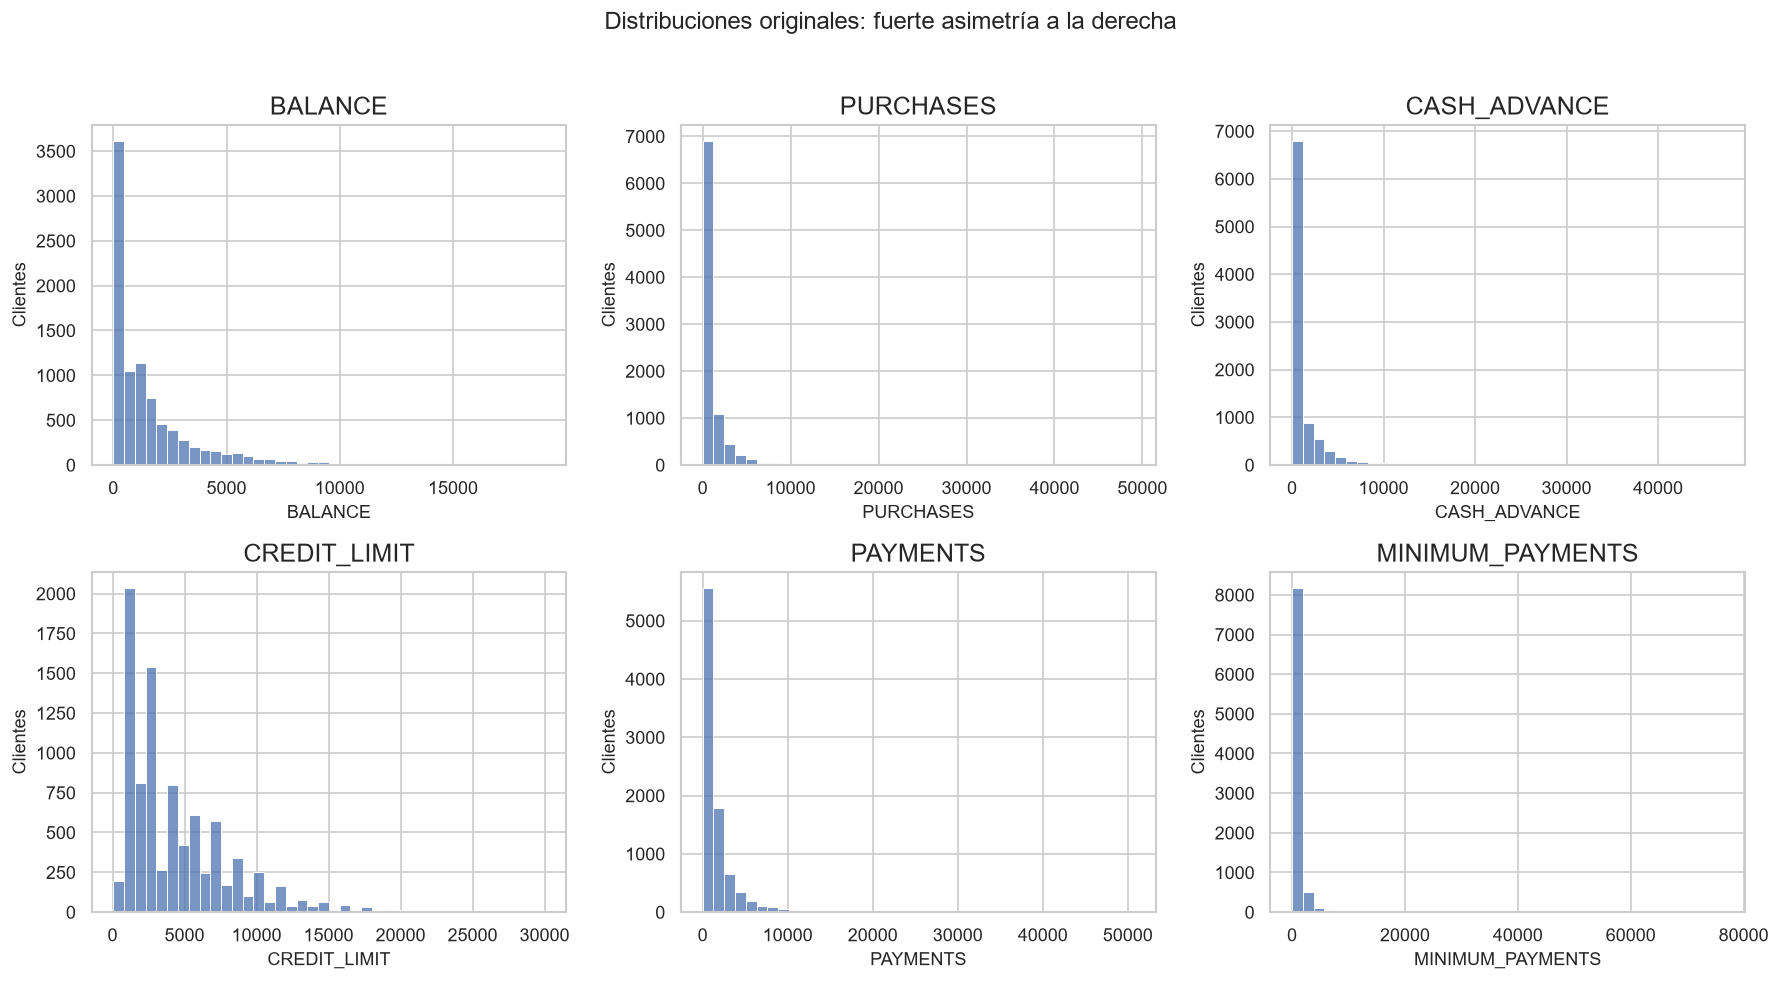

,asimetría
MINIMUM_PAYMENTS,13.85
PURCHASES,8.14
PAYMENTS,5.91
CASH_ADVANCE,5.17
BALANCE,2.39
CREDIT_LIMIT,1.52


In [10]:
# Distribuciones de variables monetarias y de comportamiento
distribution_cols = [
    "BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT",
    "PAYMENTS", "MINIMUM_PAYMENTS",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, ax in zip(distribution_cols, axes.ravel()):
    sns.histplot(df[col], bins=40, ax=ax, color="#4C72B0")
    ax.set_title(col)
    ax.set_ylabel("Clientes")
plt.suptitle("Distribuciones originales: fuerte asimetría a la derecha", y=1.02)
plt.tight_layout()
plt.show()

skewness = df[distribution_cols].skew().sort_values(ascending=False)
display(skewness.rename("asimetría").to_frame())


### Escalado

K-Means, PCA y casi todos los algoritmos de distancia son **sensibles a la escala**. `CREDIT_LIMIT` llega a miles y `PURCHASES_FREQUENCY` está entre 0 y 1: sin escalar, las variables grandes dominarían. Estandarizamos (media 0, desviación 1).

In [11]:
# Estandarización: cada variable queda con media≈0 y desviación≈1
scaler = StandardScaler()
X = scaler.fit_transform(df)

scaled_check = pd.DataFrame(
    {"media": X.mean(axis=0), "desviación": X.std(axis=0)},
    index=df.columns,
)
display(scaled_check.round(3))
print(f"Matriz escalada: {X.shape}")


,media,desviación
BALANCE,0.00,1.00
BALANCE_FREQUENCY,0.00,1.00
PURCHASES,0.00,1.00
ONEOFF_PURCHASES,0.00,1.00
INSTALLMENTS_PURCHASES,0.00,1.00
CASH_ADVANCE,0.00,1.00
PURCHASES_FREQUENCY,-0.00,1.00
ONEOFF_PURCHASES_FREQUENCY,-0.00,1.00
PURCHASES_INSTALLMENTS_FREQUENCY,0.00,1.00
CASH_ADVANCE_FREQUENCY,0.00,1.00


Matriz escalada: (8950, 17)


## PCA

Con 17 variables no podemos pintar un scatter directo. Usamos PCA para (1) ver cuánta información retiene cada componente y (2) proyectar a 2D.

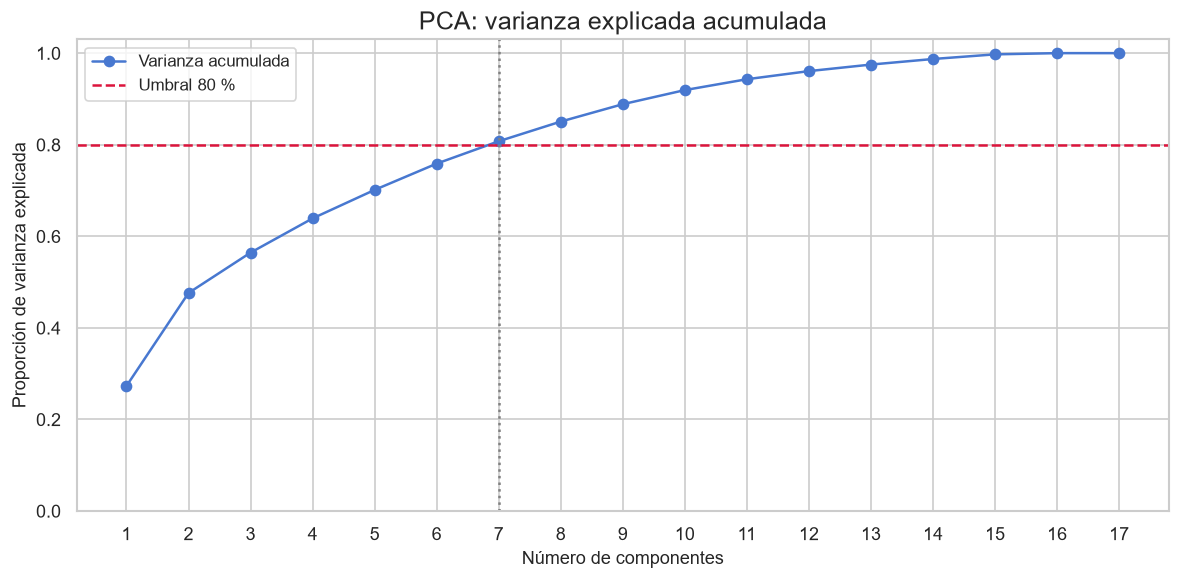

Componentes para explicar ≥80 %: 7
Varianza retenida: 80.75%


In [12]:
# PCA completo y selección del número de componentes para retener al menos el 80 %
pca_full = PCA()
pca_full.fit(X)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
n_components_80 = int(np.argmax(cumulative >= 0.80) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
components = np.arange(1, len(explained) + 1)
ax.plot(components, cumulative, marker="o", label="Varianza acumulada")
ax.axhline(0.80, color="crimson", linestyle="--", label="Umbral 80 %")
ax.axvline(n_components_80, color="gray", linestyle=":")
ax.set(
    xlabel="Número de componentes",
    ylabel="Proporción de varianza explicada",
    title="PCA: varianza explicada acumulada",
    xticks=components,
    ylim=(0, 1.03),
)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Componentes para explicar ≥80 %: {n_components_80}")
print(f"Varianza retenida: {cumulative[n_components_80 - 1]:.2%}")


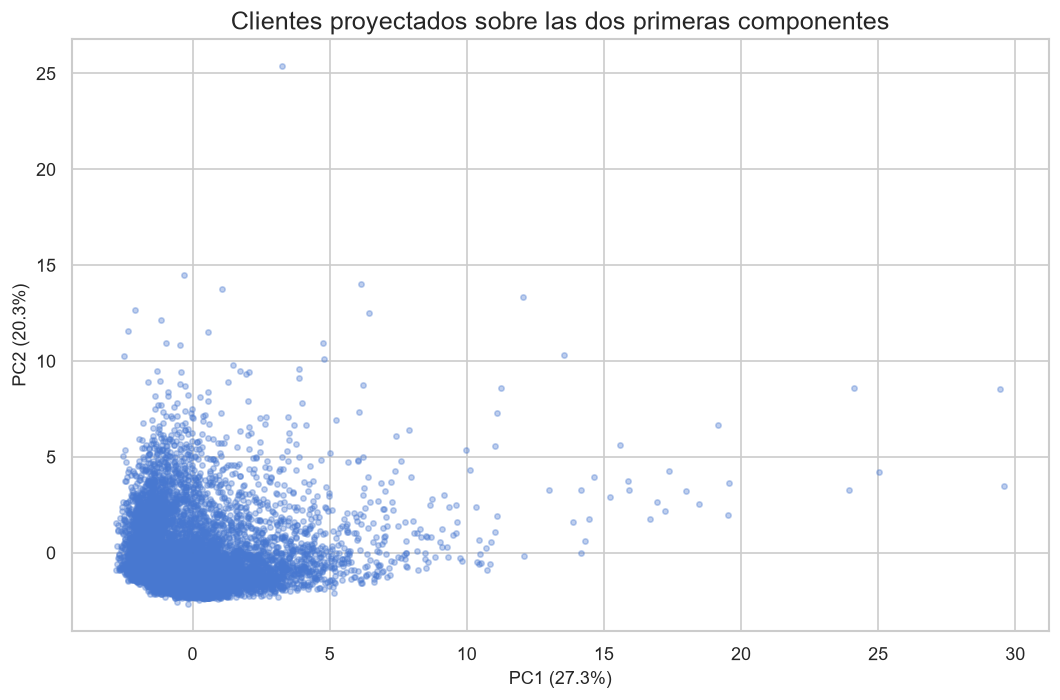

Varianza explicada en 2D: 47.61%


In [13]:
# Proyección PCA bidimensional
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

plt.figure(figsize=(9, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], s=10, alpha=0.35)
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})")
plt.title("Clientes proyectados sobre las dos primeras componentes")
plt.tight_layout()
plt.show()

print(f"Varianza explicada en 2D: {pca_2d.explained_variance_ratio_.sum():.2%}")


A diferencia de las setas, aquí no vemos grupos separados a simple vista: es más bien una **nube continua**. El clustering nos ayudará a trazar fronteras útiles dentro de ella.

## Clustering: ¿cuántos segmentos? Codo + Silhouette

,k,inercia,silhouette
0,2,"127,784.53",0.21
1,3,"111,973.97",0.24
2,4,"99,061.94",0.20
3,5,"91,490.50",0.19
4,6,"84,826.59",0.20
5,7,"79,506.96",0.21
6,8,"74,484.88",0.22


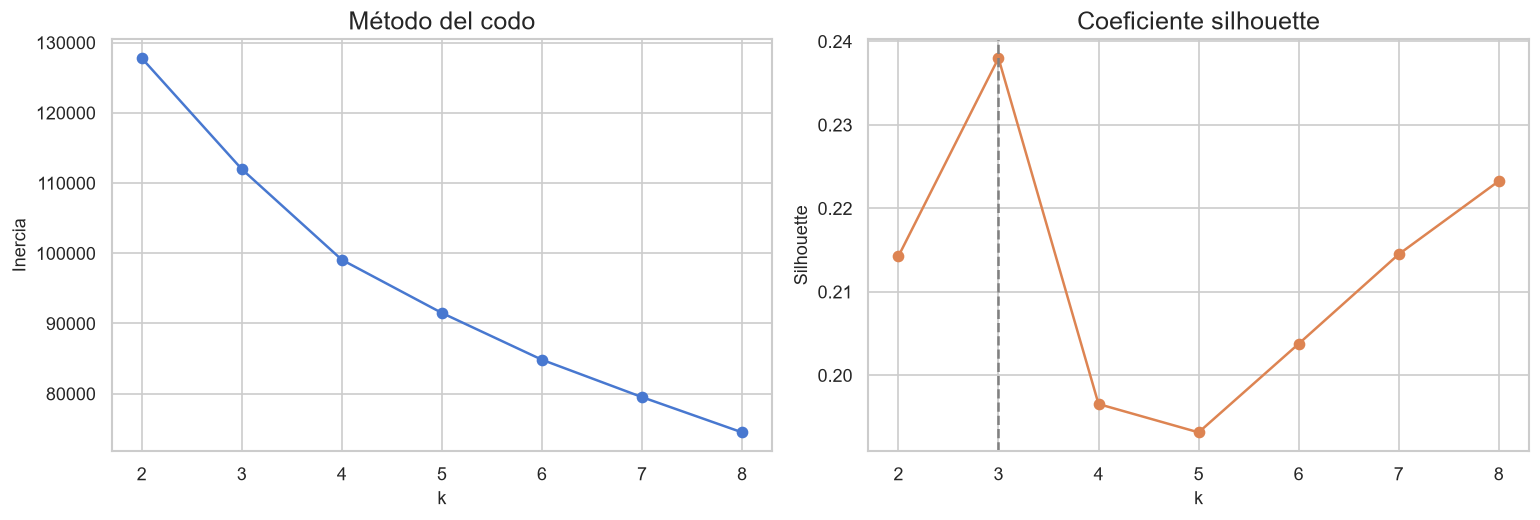

k seleccionado: 3 (silhouette=0.238)


In [14]:
# Selección de k mediante inercia y silhouette
k_values = list(K_VALUES)
inercias, silhouettes = [], []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=KMEANS_N_INIT)
    labels = model.fit_predict(X)
    inercias.append(model.inertia_)
    silhouettes.append(
        silhouette_score(
            X, labels, sample_size=min(EVALUATION_SAMPLE_SIZE, len(X)), random_state=RANDOM_STATE
        )
    )

best_k = k_values[int(np.argmax(silhouettes))]
selection_results = pd.DataFrame({
    "k": k_values,
    "inercia": inercias,
    "silhouette": silhouettes,
})
display(selection_results.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(k_values, inercias, marker="o")
axes[0].set(title="Método del codo", xlabel="k", ylabel="Inercia")
axes[1].plot(k_values, silhouettes, marker="o", color="#DD8452")
axes[1].axvline(best_k, color="gray", linestyle="--")
axes[1].set(title="Coeficiente silhouette", xlabel="k", ylabel="Silhouette")
plt.tight_layout()
plt.show()

print(f"k seleccionado: {best_k} (silhouette={max(silhouettes):.3f})")


### K-Means final

El máximo de *silhouette* se obtiene con **3 segmentos**. La puntuación es moderada, por lo
que los grupos deben interpretarse como perfiles de comportamiento útiles, no como
categorías naturales perfectamente separadas.


In [15]:
# Modelo K-Means final y tamaño de los segmentos
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=KMEANS_N_INIT)
labels_kmeans = kmeans.fit_predict(X)

cluster_sizes = (
    pd.Series(labels_kmeans, name="cluster")
      .value_counts()
      .sort_index()
      .rename("clientes")
      .to_frame()
)
cluster_sizes["porcentaje"] = 100 * cluster_sizes["clientes"] / len(X)
display(cluster_sizes.round(2))


,clientes,porcentaje
cluster,,
0,6119,68.37
1,1235,13.80
2,1596,17.83


### Dendrograma

Las métricas permiten comparar la compactación, pero no convierten automáticamente a un
algoritmo en la mejor solución de negocio. El dendrograma aporta una vista jerárquica y
muestra que la frontera entre grupos no es totalmente nítida.


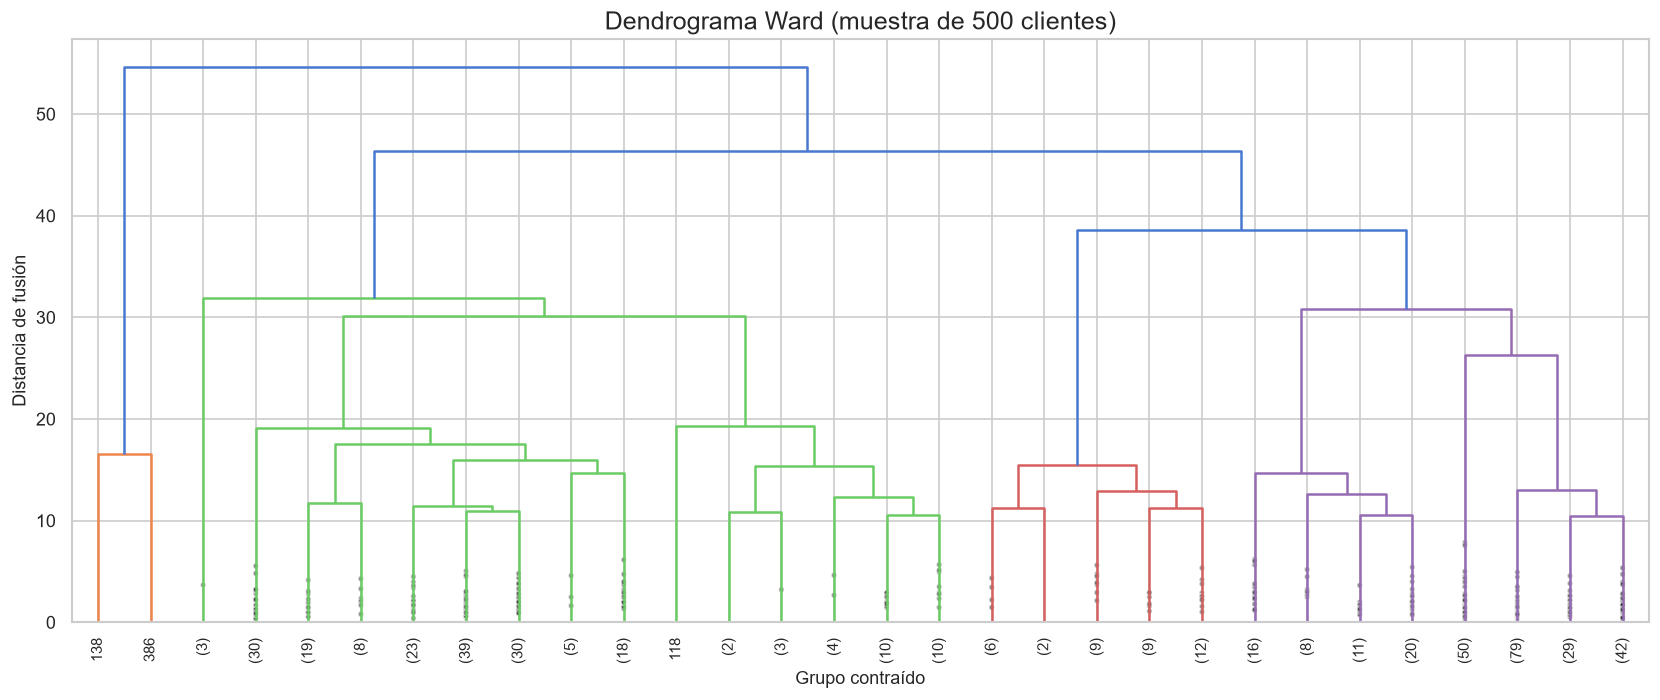

In [16]:
# Dendrograma sobre una muestra para mantener la visualización legible
dendro_idx = np.random.default_rng(RANDOM_STATE).choice(
    len(X), size=min(DENDROGRAM_SAMPLE_SIZE, len(X)), replace=False
)
linkage_matrix = linkage(X[dendro_idx], method="ward")

plt.figure(figsize=(14, 6))
dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True,
)
plt.title("Dendrograma Ward (muestra de 500 clientes)")
plt.xlabel("Grupo contraído")
plt.ylabel("Distancia de fusión")
plt.tight_layout()
plt.show()


### DBSCAN: ¿hay clusters de densidad aquí?

DBSCAN se prueba sobre PCA(2) con `eps=0.35` y `min_samples=20` como configuración
exploratoria, no como parámetros optimizados. Si concentra casi todos los clientes en
una región y separa solo ruido, indica que esta proyección se parece más a una nube
continua que a varios grupos densos.

Clusters encontrados: 1
Clientes marcados como ruido: 681 (7.6%)


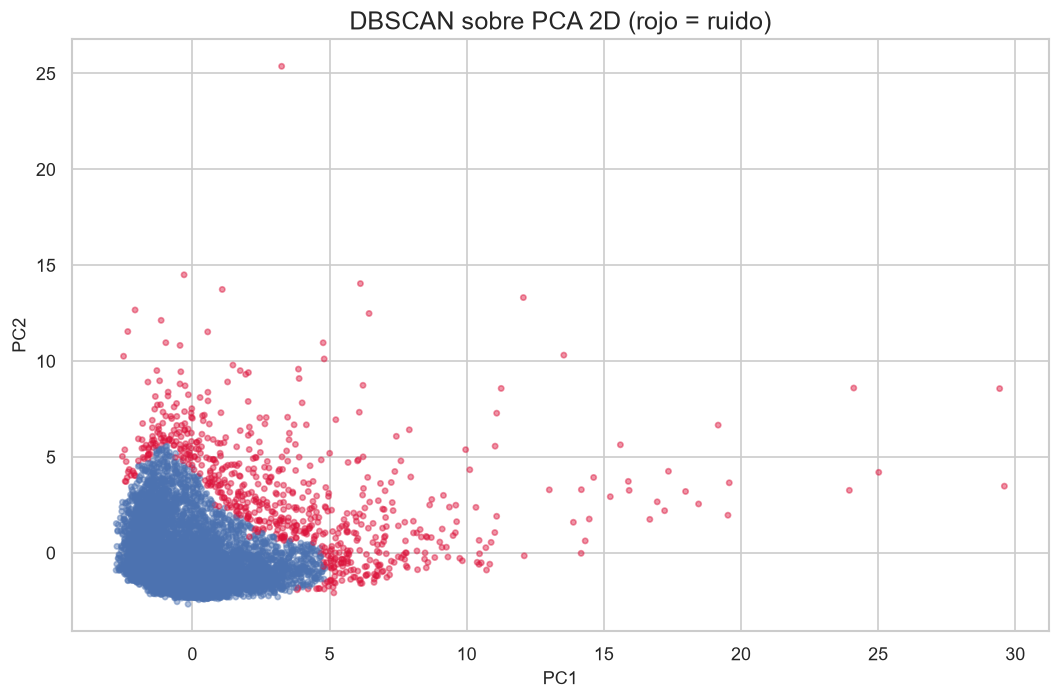

In [17]:
# DBSCAN sobre PCA(2): una gran región densa y observaciones de ruido
dbscan = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
labels_dbscan = dbscan.fit_predict(X_pca_2d)

n_dbscan_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
noise_rate = np.mean(labels_dbscan == -1)
print(f"Clusters encontrados: {n_dbscan_clusters}")
print(f"Clientes marcados como ruido: {(labels_dbscan == -1).sum():,} ({noise_rate:.1%})")

plt.figure(figsize=(9, 6))
palette = np.where(labels_dbscan == -1, "crimson", "#4C72B0")
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=palette, s=10, alpha=0.45)
plt.title("DBSCAN sobre PCA 2D (rojo = ruido)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


### Comparativa de algoritmos

K-Means produce un segmento mayoritario y dos grupos más específicos. Para comprobar si
esta partición depende demasiado del algoritmo, la contrastamos con clustering
aglomerativo y una mezcla gaussiana.

Sin etiqueta, comparamos con **métricas internas**: *silhouette* y
*Calinski-Harabasz* (más alto = mejor) y *Davies-Bouldin* (más bajo = mejor).


In [18]:
# Comparación de K-Means, Aglomerativo y Gaussian Mixture
rng = np.random.default_rng(RANDOM_STATE)
eval_idx = rng.choice(len(X), size=min(EVALUATION_SAMPLE_SIZE, len(X)), replace=False)

def evaluar(nombre, labels, data):
    labels_eval = np.asarray(labels)[eval_idx]
    data_eval = data[eval_idx]
    return {
        "algoritmo": nombre,
        "silhouette": silhouette_score(data_eval, labels_eval),
        "davies_bouldin": davies_bouldin_score(data_eval, labels_eval),
        "calinski_harabasz": calinski_harabasz_score(data_eval, labels_eval),
    }

agglomerative = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
labels_agg = agglomerative.fit_predict(X)

gmm = GaussianMixture(
    n_components=best_k, covariance_type="full",
    random_state=RANDOM_STATE, n_init=3,
)
labels_gmm = gmm.fit_predict(X)

comparison = pd.DataFrame([
    evaluar("K-Means", labels_kmeans, X),
    evaluar("Aglomerativo", labels_agg, X),
    evaluar("Gaussian Mixture", labels_gmm, X),
]).set_index("algoritmo")
display(comparison.round(3))


,silhouette,davies_bouldin,calinski_harabasz
algoritmo,,,
K-Means,0.25,1.58,526.01
Aglomerativo,0.17,1.81,401.83
Gaussian Mixture,0.11,2.62,298.82


### Interpretación de la comparación

K-Means obtiene el mejor resultado de los tres algoritmos en las métricas internas
calculadas: mayor *silhouette* y Calinski-Harabasz, y menor Davies-Bouldin. Esto respalda
su uso como modelo final en este dataset, aunque las métricas describen compactación y
separación, no valor comercial.

### Visualización de los segmentos (t-SNE)

DBSCAN concentra prácticamente todos los clientes en una única región y separa una
minoría como ruido. Esto respalda la idea de una nube continua y hace que K-Means sea
más útil para una segmentación exhaustiva. A continuación usamos t-SNE solamente como
herramienta visual; no evaluamos los clusters en este espacio.


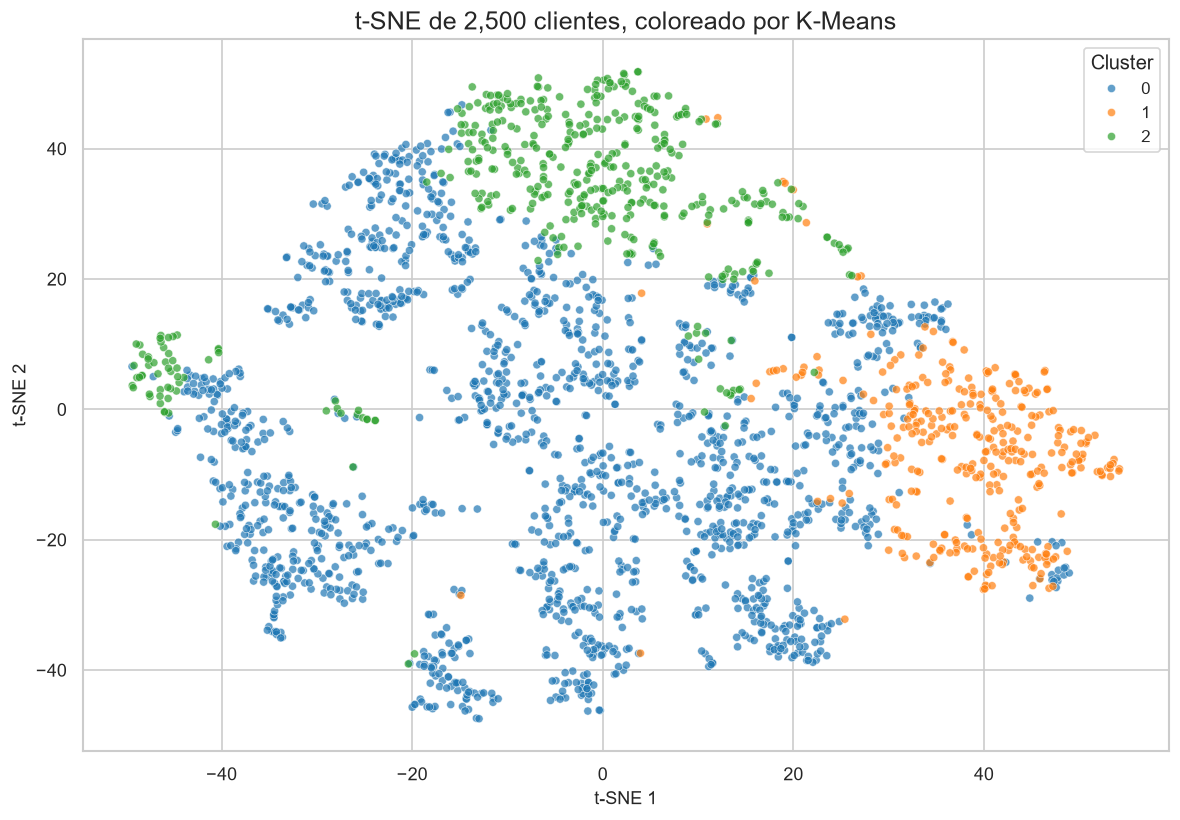

In [19]:
# t-SNE sobre una muestra estratificada por los segmentos de K-Means
sample_parts = []
sample_target = TSNE_SAMPLE_SIZE
for cluster in np.unique(labels_kmeans):
    idx = np.flatnonzero(labels_kmeans == cluster)
    n = max(1, round(sample_target * len(idx) / len(X)))
    sample_parts.append(
        np.random.default_rng(RANDOM_STATE + int(cluster)).choice(
            idx, size=min(n, len(idx)), replace=False
        )
    )
tsne_idx = np.concatenate(sample_parts)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1000,
    random_state=RANDOM_STATE,
)
X_tsne = tsne.fit_transform(X[tsne_idx])

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=labels_kmeans[tsne_idx].astype(str),
    palette="tab10",
    s=24,
    alpha=0.7,
)
plt.title(f"t-SNE de {len(tsne_idx):,} clientes, coloreado por K-Means")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


## Interpretación de los segmentos

t-SNE permite apreciar regiones dominadas por cada cluster, junto con zonas de
transición. La superposición es coherente con el *silhouette* moderado: los segmentos
son distintos en promedio, aunque algunos clientes tienen perfiles intermedios.

Lo más importante en segmentación es responder **qué caracteriza a cada grupo**.
Calculamos la media de cada variable por cluster y la estandarizamos entre clusters
(rojo = por encima de la media; azul = por debajo).


,segmento,clientes,BALANCE,PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT
cluster,,,,,,,,,
0,Baja actividad,6119,799.75,505.53,330.82,0.47,"3,271.51",909.68,0.16
1,Compradores intensivos,1235,"2,220.00","4,268.52",458.42,0.95,"7,733.97","4,151.28",0.30
2,Usuarios de adelantos,1596,"3,989.14",384.53,"3,866.21",0.23,"6,675.44","3,019.11",0.03


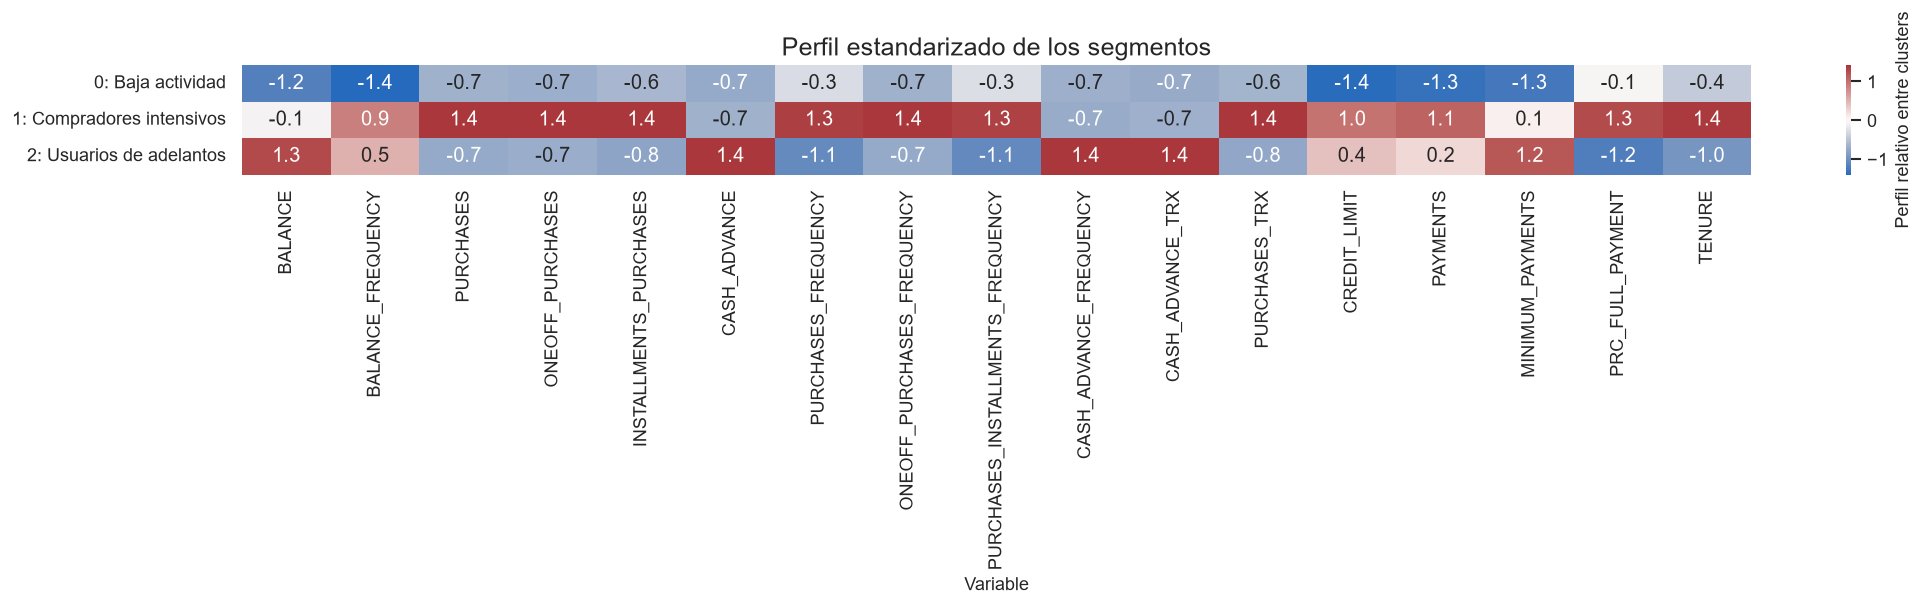

In [20]:
# Perfil de cada segmento en las unidades originales
segmented = df.copy()
segmented.insert(0, "CUST_ID", customer_ids.to_numpy())
segmented["cluster"] = labels_kmeans

profiles = segmented.drop(columns="CUST_ID").groupby("cluster").mean()
profile_z = (profiles - profiles.mean()) / profiles.std(ddof=0)

purchase_cluster = int(profiles["PURCHASES"].idxmax())
cash_cluster = int(profiles["CASH_ADVANCE"].idxmax())
remaining_cluster = int(
    next(c for c in profiles.index if c not in {purchase_cluster, cash_cluster})
)
segment_names = {
    purchase_cluster: "Compradores intensivos",
    cash_cluster: "Usuarios de adelantos",
    remaining_cluster: "Baja actividad",
}
segmented["segmento"] = segmented["cluster"].map(segment_names)

summary_cols = [
    "BALANCE", "PURCHASES", "CASH_ADVANCE", "PURCHASES_FREQUENCY",
    "CREDIT_LIMIT", "PAYMENTS", "PRC_FULL_PAYMENT",
]
business_summary = profiles[summary_cols].copy()
business_summary.insert(
    0, "clientes", pd.Series(labels_kmeans).value_counts().sort_index()
)
business_summary.insert(
    0, "segmento", pd.Series(segment_names)
)
display(business_summary.round(2))

plt.figure(figsize=(18, 5))
sns.heatmap(
    profile_z,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".1f",
    cbar_kws={"label": "Perfil relativo entre clusters"},
)
plt.yticks(
    np.arange(len(profile_z)) + 0.5,
    [f"{i}: {segment_names[i]}" for i in profile_z.index],
    rotation=0,
)
plt.title("Perfil estandarizado de los segmentos")
plt.xlabel("Variable")
plt.ylabel("")
plt.tight_layout()
plt.show()


### Lectura de negocio

- **Baja actividad**: concentra a la mayoría; presenta importes y límites inferiores a
  la media. Conviene activar el uso con ofertas de bajo coste y vigilar clientes
  inactivos antes de invertir en campañas.
- **Compradores intensivos**: mayor frecuencia e importe de compras, límite y pagos.
  Es el segmento con más potencial para fidelización, beneficios y *cross-selling*.
- **Usuarios de adelantos**: saldo y adelantos de efectivo elevados, menor frecuencia
  de compra y menor pago completo. Requiere seguimiento de riesgo y comunicación sobre
  costes, sin asumir que todos sus integrantes estén en mora.

Los nombres son descripciones analíticas, no etiquetas permanentes. Antes de desplegar
acciones comerciales habría que validar estabilidad temporal, rentabilidad y criterios
de riesgo.


## Detección de anomalías (Isolation Forest)

Isolation Forest identifica comportamientos estadísticamente atípicos. El 3 % de
contaminación es una hipótesis de análisis declarada, no una estimación de fraude. Los
casos detectados requieren revisión antes de cualquier decisión.

Anomalías detectadas: 269 (3.0%)


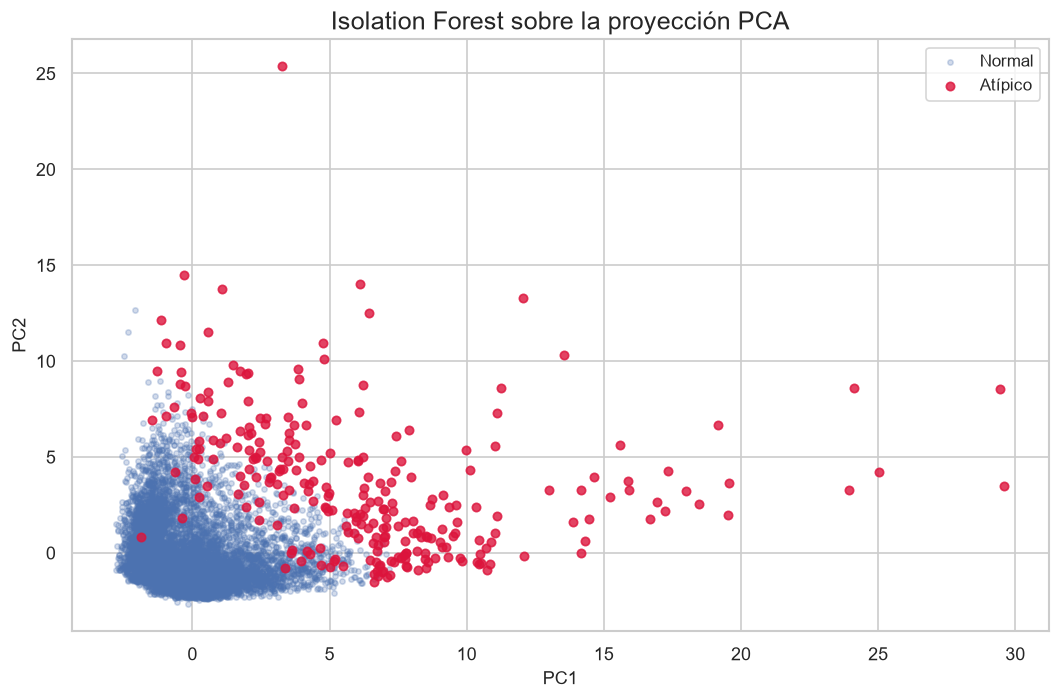

,CUST_ID,segmento,anomaly_score,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
550,C10574,Compradores intensivos,0.74,"11,547.52","49,039.57",558.17,"22,500.00","46,930.60"
138,C10144,Compradores intensivos,0.74,"19,043.14","22,009.92",0.00,"18,000.00","23,018.58"
4515,C14640,Compradores intensivos,0.73,"6,956.38","11,500.94","15,133.53","14,000.00","20,122.01"
153,C10159,Compradores intensivos,0.73,"13,673.08","9,792.23","2,444.45","20,000.00","11,717.31"
1256,C11300,Compradores intensivos,0.73,"4,010.62","40,040.71",0.00,"18,000.00","33,994.73"
501,C10523,Compradores intensivos,0.73,"13,479.29","41,050.40",0.00,"17,000.00","36,066.75"
3806,C13914,Usuarios de adelantos,0.72,"14,100.25","4,995.80","20,712.67","16,500.00","20,418.33"
1604,C11657,Compradores intensivos,0.72,"3,391.70","38,902.71",0.00,"18,000.00","35,843.63"
970,C11004,Compradores intensivos,0.72,"3,108.39","26,582.34",0.00,"28,000.00","26,557.10"
5358,C15510,Compradores intensivos,0.72,"6,372.18","22,101.78","19,513.47","7,500.00","39,461.97"


In [21]:
# Isolation Forest: detección no supervisada de los comportamientos más atípicos
isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=ANOMALY_CONTAMINATION,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
anomaly_label = isolation_forest.fit_predict(X)
anomaly_score = -isolation_forest.score_samples(X)  # mayor = más atípico
is_anomaly = anomaly_label == -1

segmented["es_anomalia"] = is_anomaly
segmented["anomaly_score"] = anomaly_score
print(f"Anomalías detectadas: {is_anomaly.sum():,} ({is_anomaly.mean():.1%})")

plt.figure(figsize=(9, 6))
plt.scatter(
    X_pca_2d[~is_anomaly, 0], X_pca_2d[~is_anomaly, 1],
    s=10, alpha=0.25, color="#4C72B0", label="Normal",
)
plt.scatter(
    X_pca_2d[is_anomaly, 0], X_pca_2d[is_anomaly, 1],
    s=25, alpha=0.8, color="crimson", label="Atípico",
)
plt.title("Isolation Forest sobre la proyección PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

display(
    segmented.nlargest(10, "anomaly_score")[
        ["CUST_ID", "segmento", "anomaly_score", "BALANCE",
         "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]
    ].round(2)
)


---
## Conclusiones

1. La imputación con mediana y el escalado fueron imprescindibles por los valores
   ausentes, la asimetría y las escalas muy diferentes.
2. **7 componentes principales** conservan al menos el 80 % de la varianza; las dos
   primeras sirven para visualizar, pero no resumen toda la estructura.
3. El mejor resultado de K-Means en el rango estudiado es **k = 3**, con un
   *silhouette* aproximado de 0.24. Es una segmentación interpretable, aunque la
   separación geométrica es moderada.
4. Los perfiles resultantes son **Baja actividad**, **Compradores intensivos** y
   **Usuarios de adelantos**. Permiten plantear acciones diferenciadas de activación,
   fidelización y seguimiento de riesgo.
5. DBSCAN no encuentra varios grupos densos convincentes; Isolation Forest identifica
   el 3 % más atípico para revisión, no para declarar fraude automáticamente.

## Limitaciones

- Los datos cubren solo seis meses y no incluyen rentabilidad, mora, fechas ni
  variables demográficas.
- Los clusters dependen del preprocesamiento y deben comprobarse en otros periodos.
- t-SNE y PCA 2D son visualizaciones; no sustituyen las métricas sobre el espacio
  completo.
- Cualquier acción sobre riesgo o crédito requiere validación humana y controles de
  equidad.

## Key takeaways

- En clustering no existe una única verdad: métricas internas e interpretación deben
  usarse conjuntamente.
- Un cluster solo aporta valor cuando puede describirse y relacionarse con una acción.
- Las anomalías son casos prioritarios para investigar, no evidencia de fraude.

El análisis de KPIs, transformaciones logarítmicas, estabilidad y UMAP/HDBSCAN continúa
en [`workshop-clustering-creditcard-advanced.ipynb`](workshop-clustering-creditcard-advanced.ipynb).